### Part 2: OpenTheChests

This notebook implements models and training with stable baselines3 for the 3 OTC environments.

For v1 and v2, results may vary depending on the exploration.

#### Expected results :
##### v0 :
- Mean Episode Reward: 3.00 ± 0.00 
- Min/Max Reward: 3.00 / 3.00
- Mean Episode Length: 4 ± 1
##### v1 : 
- Mean Episode Reward: -5.62 ± 2.80
- Min/Max Reward: -15.00 / -3.00
- Mean Episode Length: 13 ± 1 
##### v2 : 
- Mean Episode Reward: -30.00 ± 0.00
- Min/Max Reward: -30.00 / -30.00
- Mean Episode Length: 525 ± 7

In [1]:
import warnings
import logging

# Suppress UserWarning and DeprecationWarning
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Configure logger
logger = logging.getLogger()
logger.setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import gymnasium as gym
from tqdm import tqdm
from stable_baselines3 import DQN
from sb3_contrib import RecurrentPPO


from register_envs import register_custom_envs
import utils

from random import seed

# For reproductibility
seed(1)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


#### OpenTheChests-v0 :

c:\Users\malopif\miniconda3\envs\rl\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment OpenTheChests-v0 is out of date. You should consider upgrading to version `v2`.
  logger.deprecation(


Output()

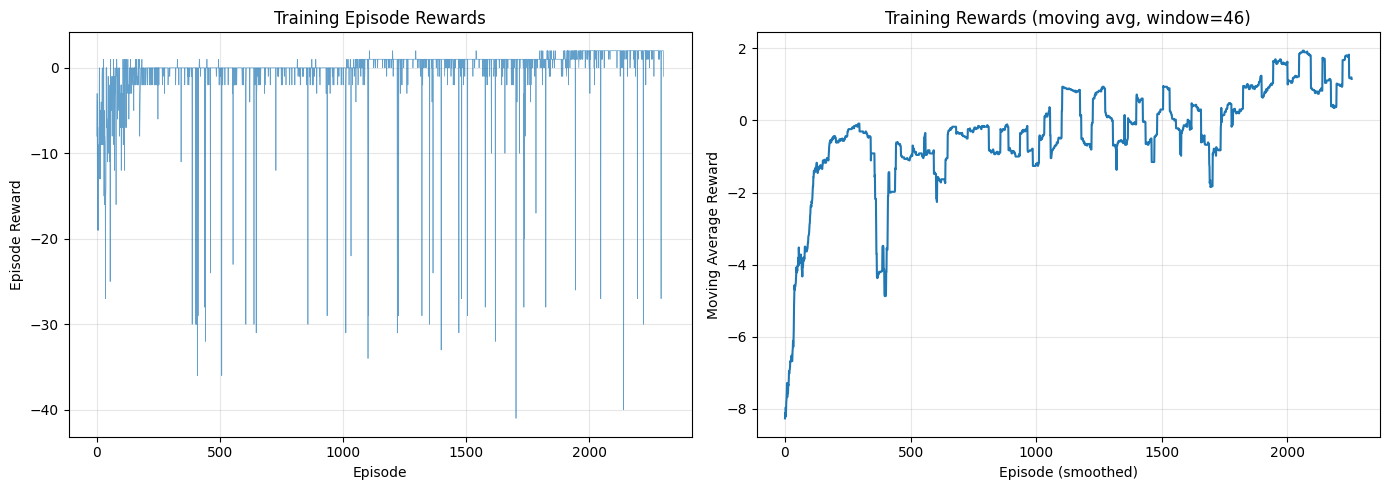

Total episodes trained: 2302
Mean reward: -0.45 ± 4.56
Best reward: 2.00
Best 20-episode avg: 2.00


In [ ]:
seed(1) #decent seed

# Initialize the OpenTheChestsGym environment
register_custom_envs()
env = gym.make("OpenTheChests-v0")

#Parameters
n_steps = 10000
lr = 1e-4


model = DQN("MultiInputPolicy", env, verbose=0, learning_rate=lr)

# custom callback : saves best versions, optional LR tracking (for debugging mainly)
callback = utils.RewardHistoryCallback(model=model, save_path="checkpoints/best_model_v0")

model.learn(n_steps, progress_bar=True, callback=callback)

callback.plot()


#### OpenTheChests-v1 :

Output()

c:\Users\malopif\miniconda3\envs\rl\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment OpenTheChests-v1 is out of date. You should consider upgrading to version `v2`.
  logger.deprecation(


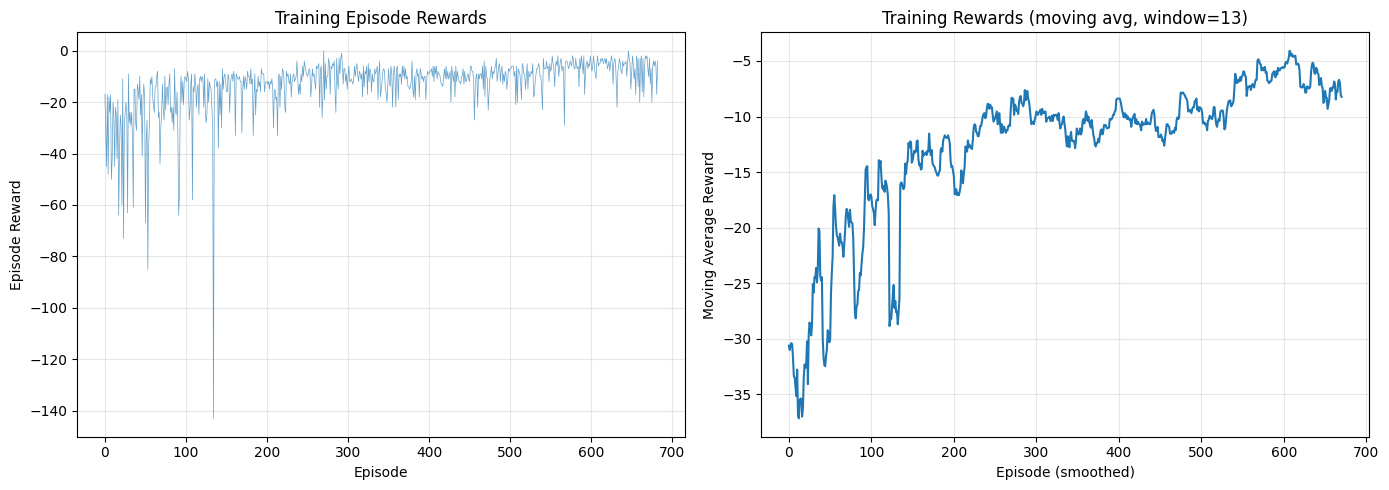

Total episodes trained: 683
Mean reward: -12.95 ± 11.15
Best reward: 0.00
Best 20-episode avg: -4.45


In [3]:
# Initialize the OpenTheChestsGym environment
env = gym.make("OpenTheChests-v1")
env = utils.FloatActionWrapper(env) #handle type conversion for sb3 compatibility
# Parameters
start_lr = 0.01
min_lr = 0.00001
lstm_h_size = 256
lstm_n_layers = 1
n_steps = 10000


scheduler = utils.CosineAnnealingLR(start_lr, min_lr)

policy_kwargs = dict(
    lstm_hidden_size=lstm_h_size,
    n_lstm_layers=lstm_n_layers,
    enable_critic_lstm=False,
    share_features_extractor=True
)

model = RecurrentPPO(
    policy="MultiInputLstmPolicy",
    env=env,
    verbose=0,
    learning_rate=scheduler,
    policy_kwargs=policy_kwargs
)

# custom callback : saves best versions, optional LR tracking (for debugging mainly)
callback = utils.RewardHistoryCallback(model=model, save_path="checkpoints/best_model_v1")

model.learn(n_steps, progress_bar=True, callback=callback)

callback.plot()

#### OpenTheChests-v2 :

In [ ]:
env = gym.make("OpenTheChests-v2")
env = utils.FloatActionWrapper(env) #handle type conversion for sb3 compatibility

# Parameters
start_lr = 3e-4
min_lr = 1e-5
lstm_h_size = 256
lstm_n_layers = 2
n_steps = 10000

scheduler = utils.CosineAnnealingLR(start_lr, min_lr)

policy_kwargs = dict(
    lstm_hidden_size=lstm_h_size,
    n_lstm_layers=lstm_n_layers,
    enable_critic_lstm=False,
    share_features_extractor=True
)

model = RecurrentPPO(
    policy="MultiInputLstmPolicy",
    env=env,
    verbose=0,
    learning_rate=scheduler,
    policy_kwargs=policy_kwargs,
    ent_coef=0.01
)

# custom callback : saves best versions, optional LR tracking (for debugging mainly)
callback = utils.RewardHistoryCallback(model=model, save_path="checkpoints/best_model_v2")

model.learn(n_steps, progress_bar=True, callback=callback)

callback.plot()

Output()